# Shipping delay: comparing a baseline and two models

The same 2,200 test rows are used throughout. Notebook 02 fits the neural network after inner validation;
this notebook loads its saved predictions and verifies the row IDs and labels before comparing them.


## Same split, both feature sets

Naive Bayes used one-hot encoding only. The network also scaled the numeric columns. Both are
built here so nothing is carried over from the other notebooks.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv('Train.csv')

X = df.drop(columns=['ID', 'Reached.on.Time_Y.N'])
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
num_cols = [c for c in X_train.columns if c not in cat_cols]

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])
train_cat = encoder.transform(X_train[cat_cols])
test_cat = encoder.transform(X_test[cat_cols])

# Naive Bayes input: one-hot only
nb_train = np.hstack([X_train[num_cols].to_numpy(), train_cat])
nb_test = np.hstack([X_test[num_cols].to_numpy(), test_cat])

# Network input: same, with the numeric columns scaled
scaler = StandardScaler()
scaler.fit(X_train[num_cols])
mlp_train = np.hstack([scaler.transform(X_train[num_cols]), train_cat])
mlp_test = np.hstack([scaler.transform(X_test[num_cols]), test_cat])

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print('Test rows:', len(y_test))
print('Test class balance:', np.bincount(y_test))

Test rows: 2200
Test class balance: [ 887 1313]


## The three predictors

GaussianNB and the majority baseline are fitted below. Run notebook 02 first to regenerate the neural network predictions.


In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score

baseline = DummyClassifier(strategy='most_frequent').fit(nb_train, y_train)
base_pred = baseline.predict(nb_test)

gnb = GaussianNB().fit(nb_train, y_train)
gnb_pred = gnb.predict(nb_test)

print('Baseline  :', round(accuracy_score(y_test, base_pred), 4))
print('GaussianNB:', round(accuracy_score(y_test, gnb_pred), 4))

Baseline  : 0.5968
GaussianNB: 0.6441


In [3]:
saved = pd.read_csv('neural_network_predictions.csv')
assert saved.row_index.is_unique
assert set(saved.row_index) == set(X_test.index)
saved = saved.set_index('row_index').loc[X_test.index]
assert np.array_equal(saved.actual.to_numpy(), y_test)
mlp_pred = (saved.probability_late.to_numpy() > 0.5).astype(int)
print('Neural network accuracy:', accuracy_score(y_test, mlp_pred))


Neural network accuracy: 0.6568181818181819


The saved neural network scores come from the exact model trained in notebook 02. No independently
initialised model is substituted here. A validation winner is not necessarily the best choice for a business cost function.


## Side by side

Accuracy alone is not enough here, but neither is recall. Both are reported below along with
precision, and with the count of orders each model actually flags as late - which is what a
warehouse would have to act on.

In [4]:
from sklearn.metrics import classification_report, precision_score, f1_score

for name, pred in [('Majority baseline', base_pred), ('GaussianNB', gnb_pred), ('Neural network', mlp_pred)]:
    print('=====', name)
    print(classification_report(y_test, pred, target_names=['on time', 'late'], zero_division=0))

===== Majority baseline
              precision    recall  f1-score   support

     on time       0.00      0.00      0.00       887
        late       0.60      1.00      0.75      1313

    accuracy                           0.60      2200
   macro avg       0.30      0.50      0.37      2200
weighted avg       0.36      0.60      0.45      2200

===== GaussianNB
              precision    recall  f1-score   support

     on time       0.53      0.97      0.69       887
        late       0.96      0.42      0.59      1313

    accuracy                           0.64      2200
   macro avg       0.74      0.70      0.64      2200
weighted avg       0.78      0.64      0.63      2200

===== Neural network
              precision    recall  f1-score   support

     on time       0.55      0.76      0.64       887
        late       0.78      0.59      0.67      1313

    accuracy                           0.66      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg

In [5]:
rows = []
for name, pred in [('Majority baseline', base_pred), ('GaussianNB', gnb_pred), ('Neural network', mlp_pred)]:
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'recall_late': recall_score(y_test, pred, pos_label=1),
        'precision_late': precision_score(y_test, pred, pos_label=1, zero_division=0),
        'f1_late': f1_score(y_test, pred, pos_label=1, zero_division=0),
        'flagged_late': int(pred.sum()),
    })

results = pd.DataFrame(rows).set_index('model').round(4)
results
results.to_csv("comparison_results.csv")
display(results)


,accuracy,recall_late,precision_late,f1_late,flagged_late
model,,,,,
Majority baseline,0.5968,1.0000,0.5968,0.7475,2200
GaussianNB,0.6441,0.4235,0.9553,0.5868,582
Neural network,0.6568,0.5880,0.7830,0.6716,986


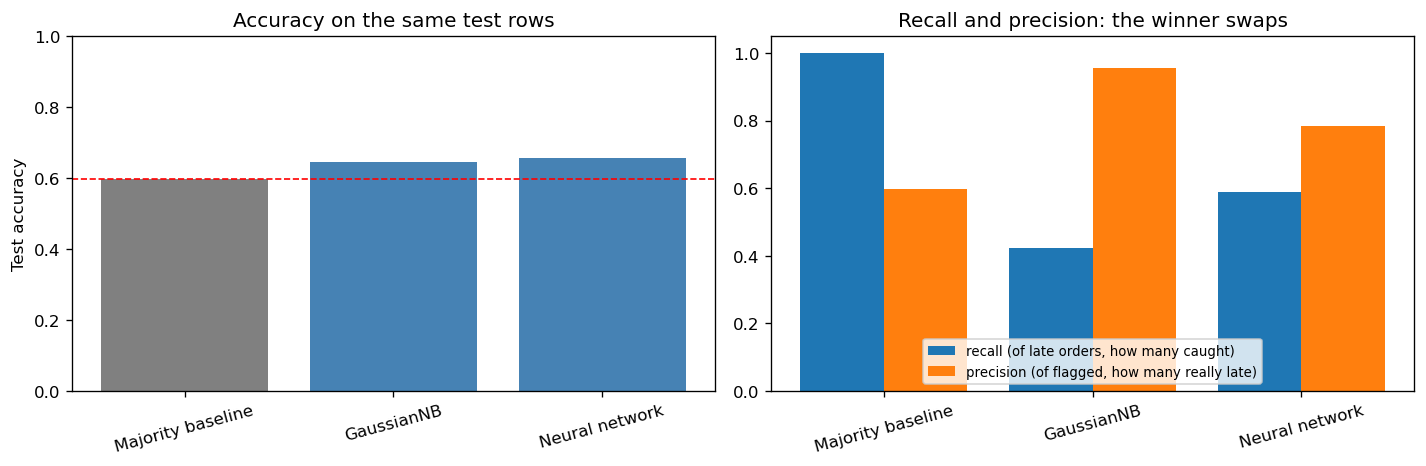

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(results))

axes[0].bar(results.index, results['accuracy'], color=['grey', 'steelblue', 'steelblue'])
axes[0].axhline(results.loc['Majority baseline', 'accuracy'], color='red', linestyle='--', linewidth=1)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Accuracy on the same test rows')

axes[1].bar(x - 0.2, results['recall_late'], 0.4, label='recall (of late orders, how many caught)')
axes[1].bar(x + 0.2, results['precision_late'], 0.4, label='precision (of flagged, how many really late)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results.index)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8, loc='lower center')
axes[1].set_title('Recall and precision: the winner swaps')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## Interpretation

Calling every order late catches every late order but also flags every on-time order. Its late-class F1 can
look competitive while its on-time-class recall is zero. Compare the confusion counts, alert workload and
missed delays rather than selecting a model from one metric alone.

The cost of a missed delay, the cost of reviewing an alert and the available capacity are not in this dataset.
No cost saving is measured here. Performance differences between these two models do not identify a feature ceiling.


## Limitations

- One previously explored split; no external or temporal evaluation.
- The neural network is selected by validation accuracy, with a fixed 0.5 decision threshold.
- Customer ratings and care-call counts need timestamps before they can support a pre-delivery prediction claim.
- A cost-based threshold would need validation data and an agreed cost model, not tuning on these test labels.
